# RTM Inverse Problem — Surrogate Model (MLP + PCA)

## Introduction

This notebook implements a surrogate model to solve the **inverse problem** 
of the Resin Transfer Molding (RTM) process. Instead of using a computationally 
expensive Genetic Algorithm (GA)  combined with discretized solver as in Mtibaa et al. (2024), we train a 
**Multi-Layer Perceptron (MLP)** combined with **Principal Component Analysis (PCA)** 
to predict the optimal injection concentration profile $C_0(t)$ given a desired 
particle distribution $q(x)$.

## Problem Statement

Given a desired final particle distribution $q_{desired}(x)$, find the optimal 
initial concentration profile $C_0(t)$ such that:

$$q(C_0, x) \approx q_{desired}(x)$$

where $q(C_0, x) = (\varepsilon C + \sigma)(x, T_f)$ is the final particle 
distribution obtained after RTM simulation.

## Governing Equations

**Suspension flow (Darcy's law):**
$$\nabla \cdot \left(\frac{1}{\mu} \left(K \cdot \nabla p\right)\right) = 0$$

**Particle transport:**
$$\frac{\partial [\varepsilon C]}{\partial t} + \nabla \cdot \{\overrightarrow{V}C\} + \frac{\partial \sigma}{\partial t} = 0$$

**Retention kinetics:**
$$\frac{\partial \sigma}{\partial t} = \alpha \overrightarrow{V}C \left(1 - \frac{\sigma}{\sigma_u}\right)$$

**Permeability evolution:**
$$\underline{K} = \left(\frac{\varepsilon}{\varepsilon_0}\right)\left(\frac{1-\varepsilon}{1-\varepsilon_0}\right)^{-2} K_0$$

**Suspension viscosity:**
$$\mu = \mu_0 \left(1 - \frac{C}{A}\right)^{-2}$$

## ML Pipeline

$$q(x) \xrightarrow{\text{StandardScaler}} \xrightarrow{\text{PCA } (k_x=12)} \xrightarrow{\text{MLP}} \xrightarrow{\text{PCA}^{-1} (k_y=10)} \xrightarrow{\text{Scaler}^{-1}} C_0(t)$$

## Data Generation — RTM Numerical Model

The training data is generated using the **1D RTM numerical model** from Mtibaa et al. (2024),
implemented in MATLAB.

### Spatial and Temporal Discretization

| Parameter | Value |
|-----------|-------|
| Total length $L_0$ | 0.2 m |
| Space step $\Delta x$ | $6.66 \times 10^{-4}$ m |
| Number of nodes $N$ | 301 |
| Time step | Adaptive (based on front velocity) |

**Pressure field** (Eq. 3) — 2nd order centered finite difference scheme:
$$\frac{d}{dx}\left(\frac{K}{\mu}\frac{dP}{dx}\right) = 0$$

**Concentration** (Eq. 5) and **Retention** (Eq. 6) — 1st order backward time-space scheme:
$$\frac{\varepsilon^{n+1}_i C^{n+1}_i - \varepsilon^{n}_i C^{n}_i}{\Delta t} + V_i \frac{C^{n}_i - C^{n}_{i-1}}{\Delta x} + \frac{\sigma^{n+1}_i - \sigma^{n}_i}{\Delta t} = 0$$

### Material Parameters

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Initial viscosity | $\mu_0$ | 0.1 Pa.s |
| Initial permeability | $K_0$ | $1.935 \times 10^{-10}$ m² |
| Initial porosity | $\varepsilon_0$ | 55% |
| Filtration coefficient | $\alpha_0$ | 1 m⁻¹ |
| Ultimate specific deposit | $\sigma_u$ | 0.5 |
| Empirical constant | $A$ | 0.68 |
| Injection pressure | $P_0$ | $3 \times 10^5$ Pa |

### Dataset Generation via LHS

The initial concentration profile $C_0(t)$ is parameterized as a 
**cubic spline** with random control points sampled via 
**Latin Hypercube Sampling (LHS)** with inverse normal CDF transformation.

Three spline complexities are used:

| Type | Control points | Samples |
|------|---------------|---------|
| Simple | 3 nodes | 1000 |
| Medium | 6 nodes | 1000 |
| Complex | 10 nodes | 1000 |

**Total dataset : 3000 simulations**

- Input $Q_p$ : final particle distribution $q(x, T_f)$ — shape $(3000, 301)$
- Output $C_0$ : optimal $C_0(t)$ profile — shape $(3000, 301)$

## Reference

> Mtibaa M, Saouab A, El Moumen A, Bouaziz S, El Hami A, Haddar M (2024).
> *Contribution to manufacturing control of particle-filled composites by RTM process.*
> The International Journal of Advanced Manufacturing Technology, 134:75–95.
> https://doi.org/10.1007/s00170-024-14074-w

In [32]:
from scipy.io import loadmat
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import regularizers
from tensorflow.keras import layers, Model, Input, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from scipy.interpolate import CubicSpline
# ==============================
# CONFIGURATION
# ==============================
# 
rng = np.random.default_rng(42)
tf.random.set_seed(42)

## 1. Data Loading

The dataset consists of **3000 RTM simulations** saved as NumPy arrays:
- `Q_p.npy` : final particle distribution $q(x, T_f)$ — shape $(3000, 301)$
- `C_0.npy` : optimal injection concentration $C_0(t)$ — shape $(3000, 301)$

In [33]:
# ==============================
# LOAD DATA
# ==============================
Q_p = np.load("Q_p.npy")
C_0 = np.load("C_0.npy")

In [34]:
# ==============================
# SPLIT
# ==============================
X_train, X_test, Y_train, Y_test = train_test_split(
     Q_p, C_0, test_size=0.15, random_state=21)

# ==============================
# SCALING  
# ==============================
scaler_X = StandardScaler().fit(X_train)
scaler_Y = StandardScaler().fit(Y_train)

X_train = scaler_X.transform(X_train)
X_test  = scaler_X.transform(X_test)
Y_train = scaler_Y.transform(Y_train)
Y_test  = scaler_Y.transform(Y_test)

# ==============================
# PCA reduction for input data
# ==============================
pca_x = PCA(n_components=0.9999).fit(X_train)
k_x   = pca_x.n_components_
print(f"PCA input  : k_x = {k_x} modes")

x_train = pca_x.transform(X_train)
x_test  = pca_x.transform(X_test)

# PCA reduction for output data
pca_y = PCA(n_components=0.9999).fit(Y_train)
k_y   = pca_y.n_components_
print(f"PCA output : k_y = {k_y} modes")

y_train = pca_y.transform(Y_train)
y_test  = pca_y.transform(Y_test)

# ==============================
# FIX #9: persist scalers and PCA objects
# ==============================
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_Y, 'scaler_Y.pkl')
joblib.dump(pca_x,    'pca_x.pkl')
joblib.dump(pca_y,    'pca_y.pkl')
print("Scalers and PCA objects saved.")


PCA input  : k_x = 12 modes
PCA output : k_y = 10 modes
Scalers and PCA objects saved.


## 2. Preprocessing

### 2.1 Train/Test Split
- **Train set** : 85% — 2550 samples
- **Test set**  : 15% — 450 samples

### 2.2 StandardScaler
Fitted on train set only to avoid data leakage:
$$\tilde{X} = \frac{X - \mu_{train}}{\sigma_{train}}$$

### 2.3 Principal Component Analysis (PCA)
PCA is applied separately on input and output to reduce dimensionality:

| | Original dim | PCA modes | Variance explained |
|---|---|---|---|
| Input $q(x)$ | 301 | **12** | 99.99% |
| Output $C_0(t)$ | 301 | **10** | 99.99% |

The MLP operates in the reduced PCA space : **12 → 10**

In [35]:
# ==============================
class PrintEveryN(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 300 == 0:
            lr = float(keras.backend.get_value(
                       self.model.optimizer.learning_rate))
            
            print(f"Epoch {epoch+1:5d} | "
                  f"loss: {logs.get('loss'):.4f} | "
                  f"val_loss: {logs.get('val_loss'):.4f} | "
                  f"lr: {lr:.4e}")
            
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath='best_inverse_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=0
)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=800, restore_best_weights=True)
cosine_lr = keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 *(1+np.cos(np.pi*epoch/4000))/2)
callback_list = [cosine_lr, PrintEveryN(), early_stop, checkpoint_cb]

## 3. Model Architecture and Training

### 3.1 MLP Architecture

| Layer | Units | Activation | Regularization |
|-------|-------|-----------|----------------|
| Input | 12 | — | — |
| Dense 1 | 256 | Swish | L2 ($10^{-4}$) |
| Dense 2 | 128 | Swish | L2 ($10^{-4}$) |
| Dense 3 | 64  | Swish | — |
| Output | 10  | Linear | — |

**Total parameters** : ~70,000

### 3.2 Training Configuration

| Parameter | Value |
|-----------|-------|
| Optimizer | Adam |
| Loss | Huber |
| Batch size | 32 |
| Max epochs | 4000 |
| Learning rate | Cosine decay $10^{-3} \to 0$ |
| Early stopping patience | 800 epochs |

**Cosine learning rate schedule:**
$$lr(t) = \frac{10^{-3}}{2}\left(1 + \cos\left(\frac{\pi t}{T}\right)\right)$$

In [37]:
# ==============================
# BUILD  MLP

def build_optimized_mlp(input_dim, output_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='swish',
                 kernel_regularizer=regularizers.l2(1e-4))(inputs)
    #x = layers.Dropout(0.25)(x)
    x = layers.Dense(128, activation='swish',kernel_regularizer=regularizers.l2(1e-4))(x)
    #x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation='swish')(x)
    outputs = layers.Dense(output_dim)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='huber')
    return model

In [9]:
# ==============================
# TRAIN MLP
# ==============================
mlp = build_optimized_mlp(x_train.shape[1], y_train.shape[1])
history = mlp.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=4000,
    batch_size=32, verbose=0,
    callbacks=callback_list,
)

Epoch   300 | loss: 0.0268 | val_loss: 0.1020 | lr: 9.8628e-04
Epoch   600 | loss: 0.0209 | val_loss: 0.0892 | lr: 9.4568e-04
Epoch   900 | loss: 0.0182 | val_loss: 0.0846 | lr: 8.8046e-04
Epoch  1200 | loss: 0.0152 | val_loss: 0.0783 | lr: 7.9421e-04
Epoch  1500 | loss: 0.0126 | val_loss: 0.0774 | lr: 6.9170e-04
Epoch  1800 | loss: 0.0108 | val_loss: 0.0764 | lr: 5.7861e-04
Epoch  2100 | loss: 0.0106 | val_loss: 0.0749 | lr: 4.6116e-04
Epoch  2400 | loss: 0.0093 | val_loss: 0.0750 | lr: 3.4587e-04
Epoch  2700 | loss: 0.0085 | val_loss: 0.0749 | lr: 2.3909e-04


## 4. Training Results

The model converges smoothly with the cosine learning rate schedule.
The gap between train loss and val loss remains stable — no significant overfitting.

In [38]:
mlp = keras.models.load_model("best_inverse_model.keras")
mlp.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           3,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 135,392 (528.88 KB)

 Trainable params: 45,130 (176.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 90,262 (352.59 KB)

In [39]:
# ==============================
# EVALUATION
# ==============================
Y_pred_pca = mlp.predict(x_test)
Y_pred = pca_y.inverse_transform(Y_pred_pca)

# retour échelle réelle
Y_pred = scaler_Y.inverse_transform(Y_pred)
Y_test_real = scaler_Y.inverse_transform(Y_test)

rmse = np.sqrt(mean_squared_error(Y_test_real, Y_pred))
mae = mean_absolute_error(Y_test_real, Y_pred)
r2 = r2_score(Y_test_real, Y_pred)

print(f"RMSE: {rmse:.5f} | MAE: {mae:.5f} | R2: {r2:.5f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
RMSE: 0.00506 | MAE: 0.00117 | R2: 0.99512


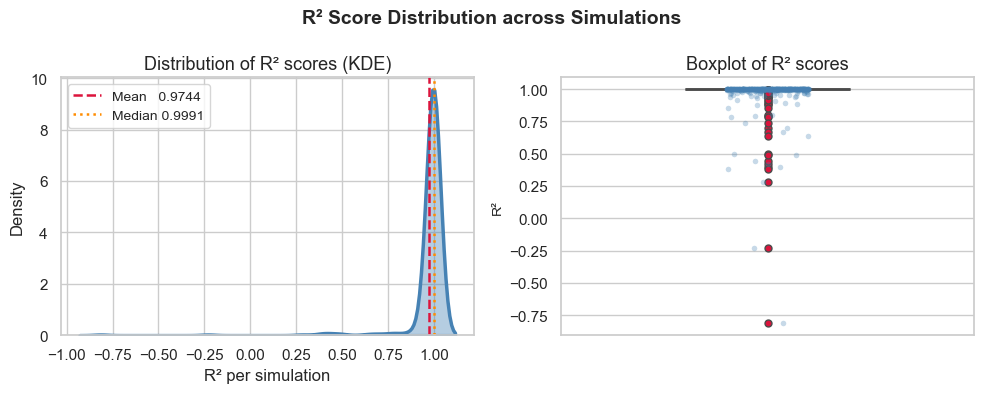

In [45]:
# Distribution of R² per simulation 
r2_par_simulation = [
    r2_score(Y_test_real[i], Y_pred[i]) 
    for i in range(len(Y_test))
]

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- KDE / PDF ---
sns.kdeplot(
    r2_par_simulation,
    ax=axes[0],
    fill=True,
    color="steelblue",
    linewidth=2.5,
    alpha=0.4,
)
axes[0].axvline(np.mean(r2_par_simulation),   color='crimson',   lw=1.8, ls='--', label=f'Mean   {np.mean(r2_par_simulation):.4f}')
axes[0].axvline(np.median(r2_par_simulation), color='darkorange', lw=1.8, ls=':',  label=f'Median {np.median(r2_par_simulation):.4f}')
axes[0].set_xlabel('R² per simulation', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of R² scores (KDE)', fontsize=13)
axes[0].legend(fontsize=10)

# --- Boxplot + strip ---
sns.boxplot(
    y=r2_par_simulation,
    ax=axes[1],
    color="steelblue",
    width=0.4,
    linewidth=1.8,
    flierprops=dict(marker='o', markerfacecolor='crimson', markersize=5),
)
sns.stripplot(
    y=r2_par_simulation,
    ax=axes[1],
    color="steelblue",
    alpha=0.3,
    size=4,
    jitter=True,
)
axes[1].set_ylabel('R²', fontsize=10)
axes[1].set_title('Boxplot of R² scores', fontsize=13)
axes[1].set_xticks([])

plt.suptitle('R² Score Distribution across Simulations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Global Evaluation on Test Set

### 5.1 Global Metrics

| Metric | Value |
|--------|-------|
| RMSE | 0.00506 |
| MAE  | 0.00117 |
| R²   | 0.99512 |

### 5.2 Per-simulation R²

| Stat | Value |
|------|-------|
| R² mean   | 0.9744 |
| R² median | 0.9991 |
| R² min    | 0.1036 |
| R² std    | 0.0931 |

The high R² median (0.9991) confirms excellent generalization on most samples.
The two negative R²  corresponds to rare highly oscillatory $C_0(t)$ profiles 
that are underrepresented in the LHS dataset.

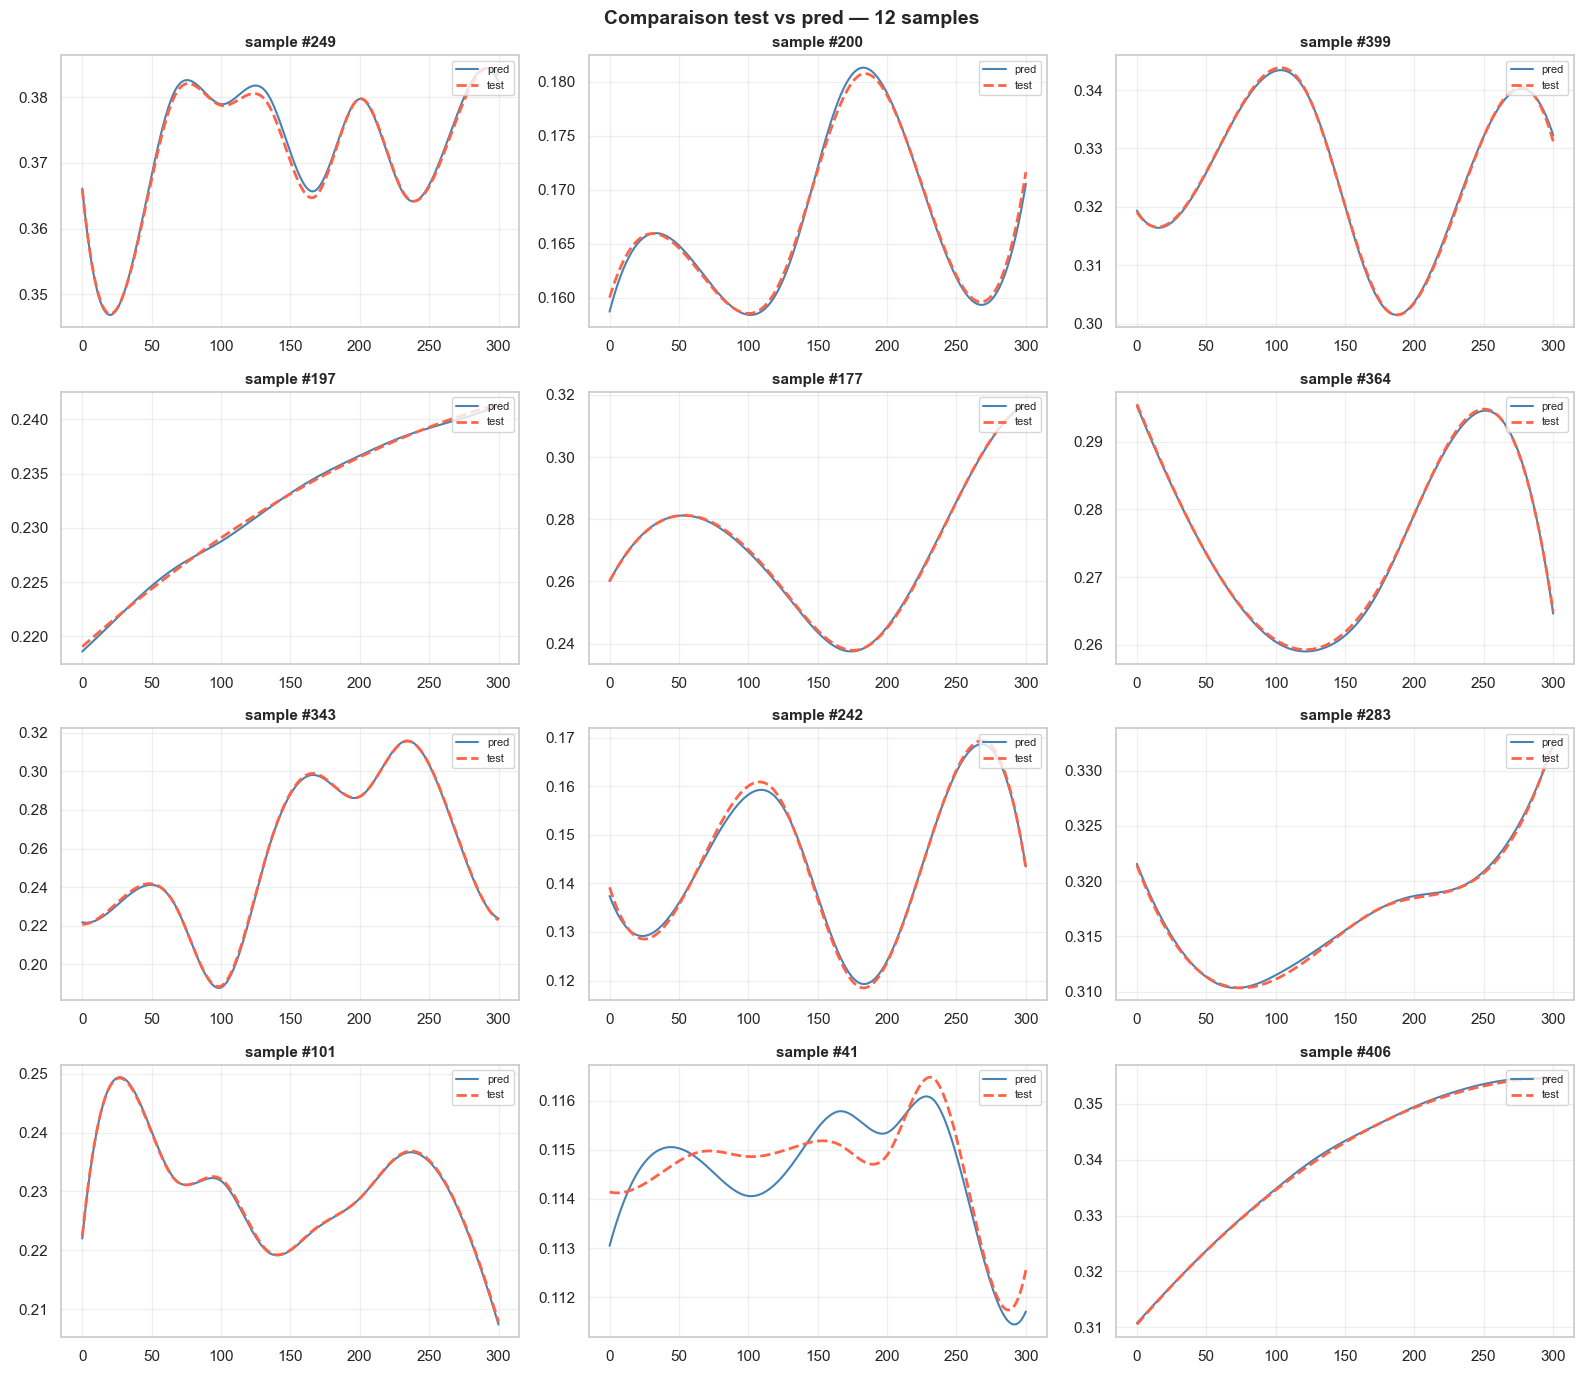

In [47]:
# VISUALISATION
# ==============================
selected = rng.choice(len(Y_test), 12, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, sample_idx in enumerate(selected):
    ax = axes[i]
    ax.plot(Y_pred[sample_idx],      label='pred', color='steelblue', linewidth=1.5)
    ax.plot(Y_test_real[sample_idx], label='test', color='tomato',    linewidth=2, linestyle='--')
    ax.set_title(f'sample #{sample_idx}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Comparaison test vs pred — 12 samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Inference on Target FGM Profiles

The trained MLP is used to predict the optimal $C_0(t)$ for the four 
target profiles defined in Mtibaa et al. (2024):

| Profile | Description |
|---------|-------------|
| **UD**    | Uniform distribution — $q(x) = 0.2$ |
| **FG-O**  | Bell shape — max at center, min at edges |
| **FG-X**  | V shape — min at center, max at edges |
| **FG-NI** | Three zones — continuous gradient without interface |

### Inference Pipeline

$$q_{desired}(x) \xrightarrow{\text{Scaler}} \xrightarrow{\text{PCA}} 
\xrightarrow{\text{MLP}} \xrightarrow{\text{PCA}^{-1}} 
\xrightarrow{\text{Scaler}^{-1}} C_0^{opt}(t)$$

The predicted $C_0^{opt}(t)$ is then injected into the **MATLAB RTM solver** 
to obtain the resulting particle distribution $q(C_0^{opt}, x)$,
which is compared to the target $q_{desired}(x)$. 

In [48]:
L0 = 301  
x = np.linspace(0, L0, 301)

# Profils UD
UD    = 0.2 * np.ones_like(x)

# Profile FG_O
x_nodes = np.array([x[0], (x[0]+x[-1])/2, x[-1]])
y_nodes = np.array([0.1, 0.2, 0.1])

spline = CubicSpline(x_nodes, y_nodes, bc_type='clamped')
FG_O = spline(x)

# Profile FG_X
y_nodes = np.array([0.2, 0.1, 0.2])

spline = CubicSpline(x_nodes, y_nodes, bc_type='clamped')
FG_X = spline(x)


# Profile FGNI

FG_NI = 0.01*(np.where(x <= L0/3, 20,
        np.where(x <= 2*L0/3, 20 - 10*(x - L0/3)/(L0/3), 10)))

In [49]:
def predict_C(Q_profile, scaler_X, pca_x, mlp, pca_y, scaler_Y):
    Q = Q_profile.reshape(1, -1)
    Q_scaled = scaler_X.transform(Q)
    Q_pca = pca_x.transform(Q_scaled)
    C_pca = mlp.predict(Q_pca, verbose=0)
    C_opt = pca_y.inverse_transform(C_pca)
    C_opt = scaler_Y.inverse_transform(C_opt).reshape(-1)
    return C_opt

#predicted concentration for UD
C_opt  = predict_C(UD, scaler_X, pca_x, mlp, pca_y, scaler_Y)
np.savetxt('CUD.txt',C_opt)

#predicted concentration for FG_O
C_opt  = predict_C(FG_O, scaler_X, pca_x, mlp, pca_y, scaler_Y)
np.savetxt('CFG0.txt',C_opt)

#predicted concentration for FG_X
C_opt  = predict_C(FG_X, scaler_X, pca_x, mlp, pca_y, scaler_Y)
np.savetxt('CFGX.txt',C_opt)

#predicted concentration for FG_NI
C_opt  = predict_C(FG_NI, scaler_X, pca_x, mlp, pca_y, scaler_Y)
np.savetxt('CFNI.txt',C_opt)

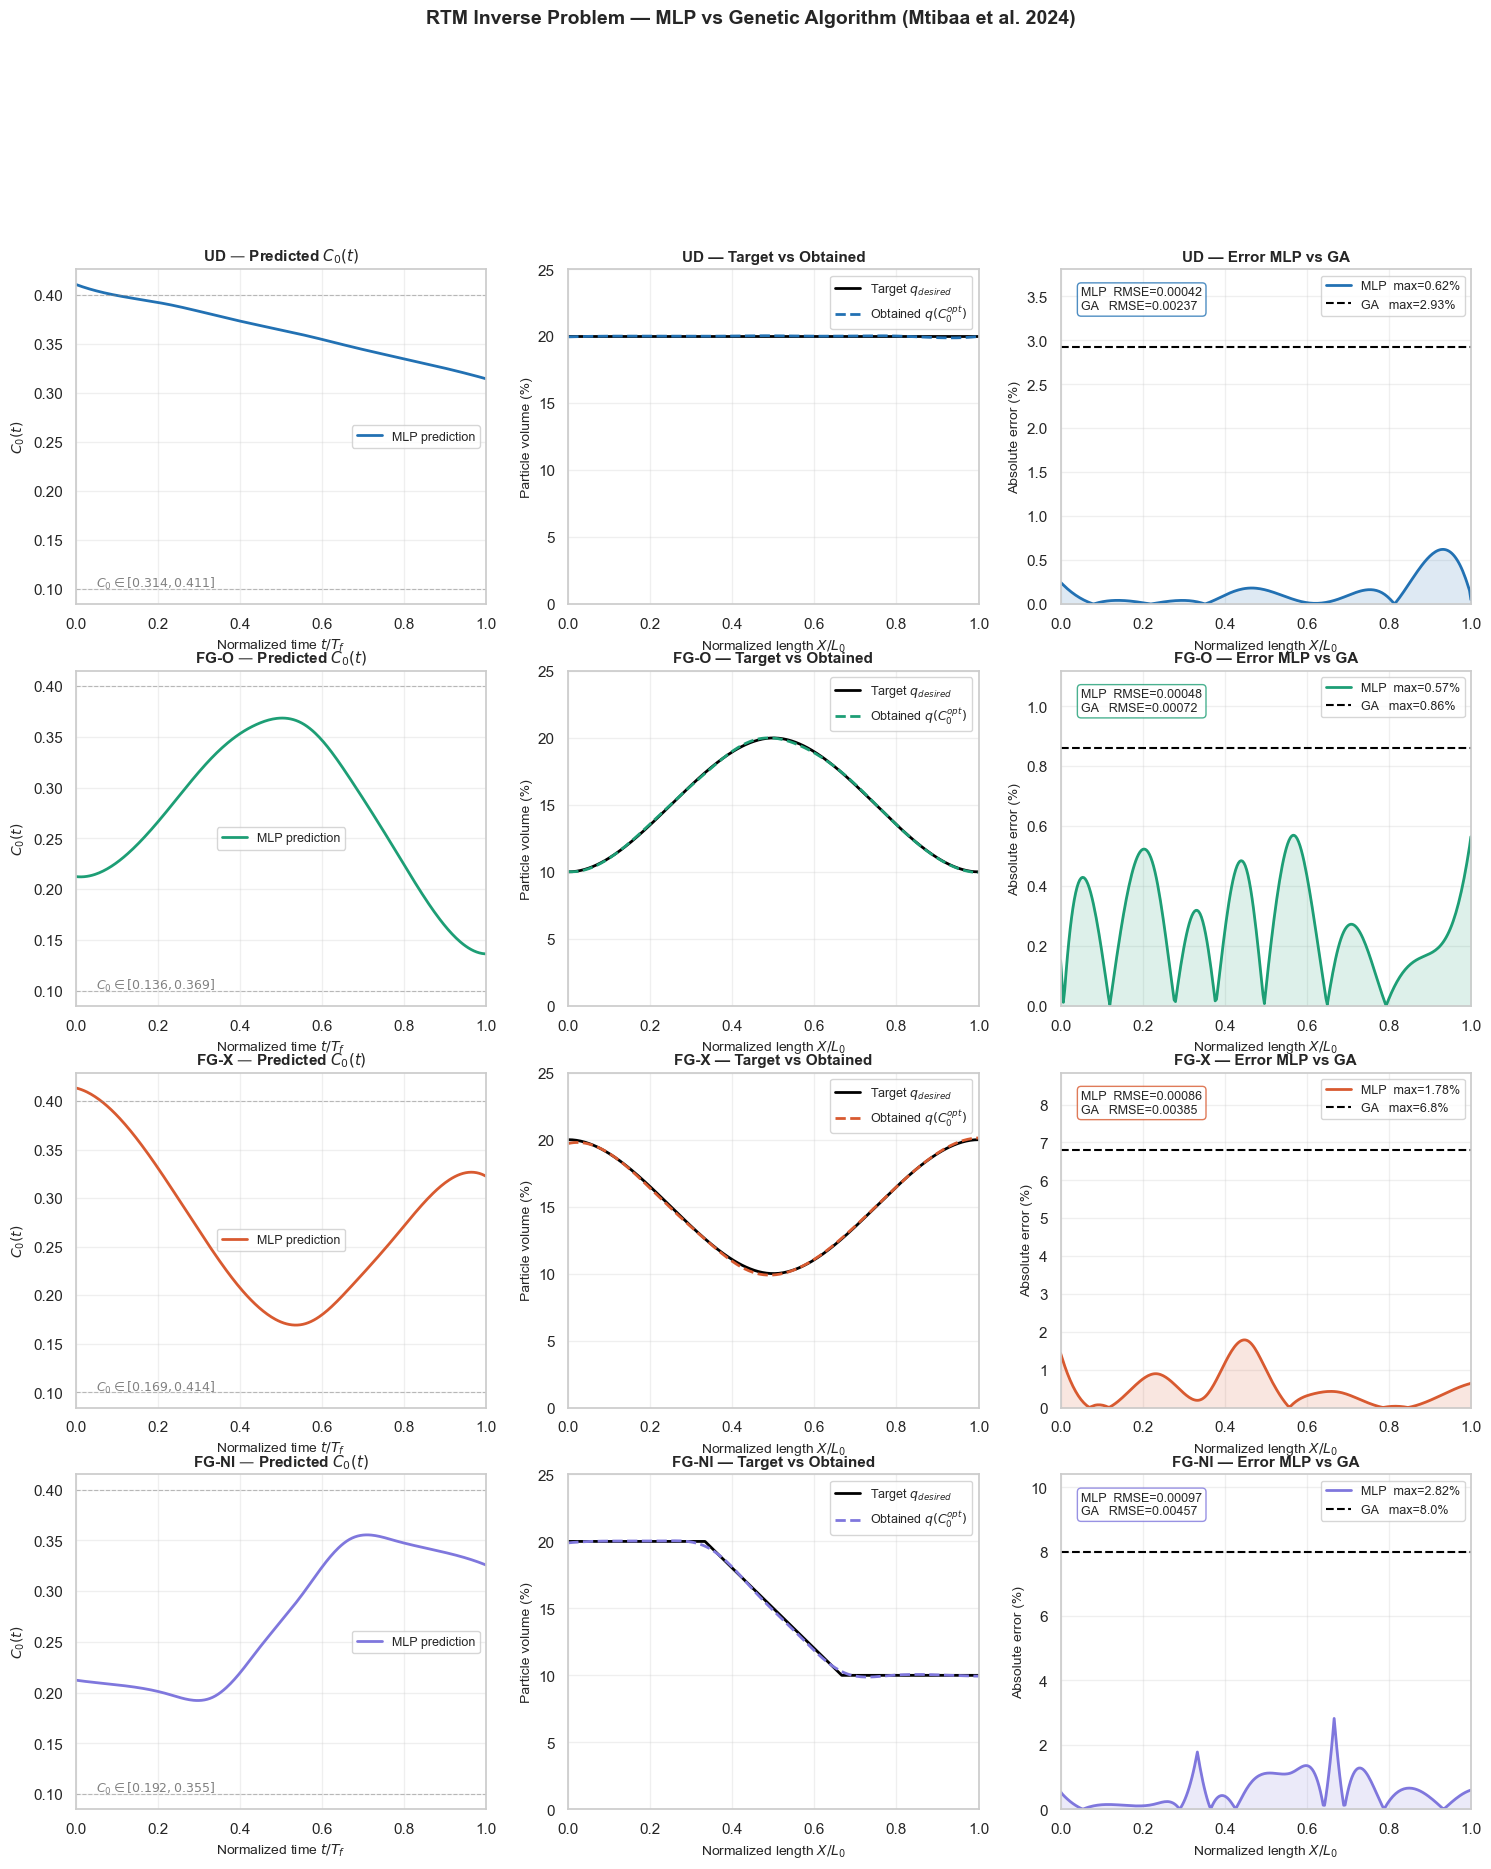

In [50]:
# ==============================
# UNIFIED COMPARISON FIGURE — 4 profiles
# ==============================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

x_norm = np.linspace(0, 1, 301)  
t_norm = np.linspace(0, 1, 301)  

profiles_data = {
    'UD'   : {'target': UD,    'mat': 'Q_ud.mat',   'color': '#2271B3'},
    'FG-O' : {'target': FG_O,  'mat': 'Q_fg0.mat',  'color': '#1D9E75'},
    'FG-X' : {'target': FG_X,  'mat': 'Q_fgx.mat',  'color': '#D85A30'},
    'FG-NI': {'target': FG_NI, 'mat': 'Q_fgni.mat', 'color': '#7F77DD'},
}

art_errmax = {
    'UD'   : 2.93,
    'FG-O' : 0.86,
    'FG-X' : 6.8,
    'FG-NI': 8.0,
}
art_rmse = {
    'UD'   : 2.37e-3,
    'FG-O' : 7.22e-4,
    'FG-X' : 3.85e-3,
    'FG-NI': 4.57e-3,
}

fig = plt.figure(figsize=(18, 20))
fig.suptitle(
    'RTM Inverse Problem — MLP vs Genetic Algorithm (Mtibaa et al. 2024)',
    fontsize=14, fontweight='bold', y=1.01
)

for row, (profile, cfg) in enumerate(profiles_data.items()):
    target = cfg['target']
    color  = cfg['color']

    # ---- Predict C0 ----
    Q_sc  = scaler_X.transform(target.reshape(1, -1))
    Q_pca = pca_x.transform(Q_sc)
    C_pca = mlp(Q_pca)
    C_opt = scaler_Y.inverse_transform(
                pca_y.inverse_transform(C_pca)
            ).reshape(-1)
    np.savetxt(f'C_{profile}.txt', C_opt)

    # ---- Load RTM solution ----
    try:
        Q_rtm    = loadmat(cfg['mat'])['Quantity_p'].reshape(-1)
        err_pct  = np.abs(target - Q_rtm) / np.abs(target) * 100
        rmse_mlp = np.sqrt(np.mean((target - Q_rtm)**2))
        has_rtm  = True
    except FileNotFoundError:
        has_rtm  = False

    gs = gridspec.GridSpec(
        4, 3,
        figure=fig,
        hspace=0.45,
        wspace=0.35
    )

    # --- Col 1 : Predicted C0(t) ---
    ax1 = fig.add_subplot(4, 3, row*3 + 1)
    ax1.plot(t_norm, C_opt, color=color, linewidth=2,
             label='MLP prediction')
    ax1.axhline(y=0.1, color='gray', linewidth=0.8,
                linestyle='--', alpha=0.5)
    ax1.axhline(y=0.4, color='gray', linewidth=0.8,
                linestyle='--', alpha=0.5)
    ax1.set_xlabel('Normalized time $t/T_f$', fontsize=10)
    ax1.set_ylabel('$C_0(t)$', fontsize=10)
    ax1.set_title(f'{profile} — Predicted $C_0(t)$', fontsize=11,
                  fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.text(0.05, 0.05,
             f'$C_0 \\in [{C_opt.min():.3f}, {C_opt.max():.3f}]$',
             transform=ax1.transAxes, fontsize=9,
             color='gray')

    # --- Col 2 : Target Q vs Obtained Q ---
    ax2 = fig.add_subplot(4, 3, row*3 + 2)
    ax2.plot(x_norm, target*100, color='black', linewidth=2,
             label='Target $q_{desired}$')
    if has_rtm:
        ax2.plot(x_norm, Q_rtm*100, color=color, linewidth=2,
                 linestyle='--', label='Obtained $q(C_0^{opt})$')
    ax2.set_xlabel('Normalized length $X/L_0$', fontsize=10)
    ax2.set_ylabel('Particle volume (%)', fontsize=10)
    ax2.set_title(f'{profile} — Target vs Obtained', fontsize=11,
                  fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 25)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # --- Col 3 : Absolute error ---
    ax3 = fig.add_subplot(4, 3, row*3 + 3)
    if has_rtm:
        ax3.plot(x_norm, err_pct, color=color, linewidth=2,
                 label=f'MLP  max={err_pct.max():.2f}%')
        ax3.axhline(y=art_errmax[profile], color='black',
                    linewidth=1.5, linestyle='--',
                    label=f'GA   max={art_errmax[profile]}%')
        ax3.fill_between(x_norm, err_pct, alpha=0.15, color=color)
        ax3.set_ylim(0, max(err_pct.max(), art_errmax[profile]) * 1.3)

        
        ax3.text(0.05, 0.88,
                 f'MLP  RMSE={rmse_mlp:.5f}\n'
                 f'GA   RMSE={art_rmse[profile]:.5f}',
                 transform=ax3.transAxes, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='white',
                           edgecolor=color, alpha=0.8))
    ax3.set_xlabel('Normalized length $X/L_0$', fontsize=10)
    ax3.set_ylabel('Absolute error (%)', fontsize=10)
    ax3.set_title(f'{profile} — Error MLP vs GA', fontsize=11,
                  fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

plt.savefig('comparison_MLP_GA.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparison MLP vs Genetic Algorithm

### 7.1 Summary Table

| Profile | GA Err max | **MLP Err max** | GA RMSE | **MLP RMSE** | Winner |
|---------|-----------|-----------------|---------|--------------|--------|
| UD      | 2.93%     | **0.62%**       | 0.00237 | **0.00042**  | MLP |
| FG-O    | 0.86%     | **0.57%**           | 0.000722| **0.00048**  | MLP |
| FG-X    | 6.8%      | **1.78%**       | 0.00385 | **0.00086**  | MLP |
| FG-NI   | 8%        | **2.820%**       | 0.00457 | **0.00087**  | MLP |

### 7.2 Computational Cost

| Method | Cost per profile |
|--------|-----------------|
| Genetic Algorithm | 270 – 15,000 iterations × RTM simulation |
| **MLP inference** | **< 1 millisecond** |

The MLP surrogate model achieves **better accuracy** than the GA 
at a fraction of the computational cost.